# Astra: Structural Code Similarity Detection for Python Programming Assignments Using AST Normalization and Damerau–Levenshtein Sequence Alignment

**Andrian Lloyd Maagma, Dejel Cyrus De Asis, John Romyr Lopez**

_CMSC 142 - Design and Analysis of Algorithms_

May 29, 2026

---


In [1]:
# Imports
import sys
from pathlib import Path
import itertools

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from astra_core import (
    CodeUnit,
    analyze_code_similarity,
)
from astra_core.pipeline.ast_processing import (
    chunk_source_code,
)
from astra_core.pipeline.distance import damerau_levenshtein_distance

print("astra_core imported successfully")

astra_core imported successfully


## 1. Introduction

### 1.1 Problem Statement

Programming labs in institutions (e.g. UPV) require students to solve identical programming tasks. Because these assignments are typically take-home, issues such as plagiarism, code reuse, and AI-generated solutions are common, motivating the need for reliable similarity detection methods.

Detecting plagiarism in programming is challenging when students apply obfuscation techniques that preserve program logic while changing superficial structure. These include renaming identifiers, modifying literals, reformatting code, altering comments, and reordering independent statements. Such changes easily defeat naive text-matching methods that rely on raw character-level comparison.

### 1.2 Motivation

Program structure is a more stable and meaningful representation than raw text for the purpose of similarity detection. Two programs that perform the same computation will share structural patterns in their ASTs regardless of how identifiers or literals are named. By operating at the structural level, a similarity system can remain robust against the obfuscation techniques most commonly employed by students in programming courses.

### 1.3 Objective

Create a pipeline that takes a set of Python source files as input and produces a ranked list of file pair similarity scores using AST normalization and sequence alignment.

## 2. Related Work

### 2.1 Text-Matching

Early plagiarism detection systems operated directly on raw source text using string matching, fingerprinting, or n-gram overlap. These approaches are computationally inexpensive but are trivially defeated by any surface-level modification. Renaming a single variable throughout a file is sufficient to reduce text similarity to near zero while preserving complete logical equivalence.

### 2.2 AST-Based Approaches

AST-based approaches operates on the full syntactic structure of the program. Systems in this category parse each submission into an abstract syntax tree and compare tree structures directly, either through tree edit distance, subtree matching, or linearized traversals. AST-based methods are significantly more robust to obfuscation because program structure is preserved under renaming and reformatting.

### 2.3 Edit Distance and Sequence Alignment Approaches

Edit distance metrics, particularly Levenshtein distance and its extensions, have been applied to code comparison through linearized representations of program structure. Smith–Waterman local sequence alignment has also been applied to detect partial similarity between submissions, identifying matching subsequences rather than requiring global alignment.


## 3. Methodology

### 3.1 System Overview

```text
Input files
    │
    ▼
Parse into AST
    │
    ▼
Normalize AST
    │
    ▼
Decompose into chunks
    │
    ▼
Convert chunks to token sequences
    │
    ▼
Pairwise chunk comparison (DP)
    │
    ▼
Best-match aggregation
    │
    ▼
Ranked similarity report
```

In [2]:
# End-to-End Pipeline Demo
# 3 submissions: a and b share the same logic;
# c is structurally different.

units = [
    CodeUnit(id="student_a.py", content="def add(x, y): return x + y"),
    CodeUnit(id="student_b.py", content="def add(a, b): return a + b"),
    CodeUnit(id="student_c.py", content="def subtract(p, q): return p - q"),
]

report = analyze_code_similarity(units, threshold=0.8)
print(report)

Total submissions: 3
Threshold: 80.00%
Flagged pairs: 3

Top Similarities:
  - student_a.py <=> student_b.py: 100.00%
  - student_a.py <=> student_c.py: 95.24%
  - student_b.py <=> student_c.py: 95.24%

FLAGGED:
  - student_a.py <=> student_b.py: 100.00%
  - student_a.py <=> student_c.py: 95.24%
  - student_b.py <=> student_c.py: 95.24%


### 3.2 AST Normalization

After parsing, each AST is normalized to eliminate sources of variation that do not reflect logical differences between programs.

The following transformations are applied during token sequence construction:

- **Identifier normalization.** All variable names, function names, class names, argument names, and attribute names are replaced with the generic placeholder `IDENT`. This ensures that two functions differing only in variable naming produce identical token sequences.

- **Literal normalization.** Numeric literals are replaced with `CONST_NUM`, string literals with `CONST_STR`, boolean literals with `CONST_BOOL`, `None` with `CONST_NONE`, and byte literals with `CONST_BYTES`. This removes sensitivity to specific constant values chosen by students.

- **Comment removal.** Python's `ast.parse()` does not include comments in the AST, so comment removal is handled automatically at no additional cost.

In [3]:
# EXAMPLE
# Two functions that are logically identical but use different variable names.
# After normalization, their token sequences are identical.

src_a = CodeUnit(id="a.py", content="def add(x, y): return x + y")
src_b = CodeUnit(id="b.py", content="def sum(l, r): return l + r")

tokens_a = chunk_source_code(src_a)[0].tokens
tokens_b = chunk_source_code(src_b)[0].tokens

print("Tokens from  def add(x, y):\n", tokens_a)
print("Tokens from  def add(l, r):\n", tokens_b)
print("Sequences identical:", tokens_a == tokens_b)

Tokens from  def add(x, y):
 ('FunctionDef', 'IDENT', 'IDENT', 'arguments', 'arg', 'ARG', 'IDENT', 'arg', 'ARG', 'IDENT', 'Return', 'BinOp', 'Name', 'IDENT', 'IDENT', 'Load', 'Add', 'Name', 'IDENT', 'IDENT', 'Load')
Tokens from  def add(l, r):
 ('FunctionDef', 'IDENT', 'IDENT', 'arguments', 'arg', 'ARG', 'IDENT', 'arg', 'ARG', 'IDENT', 'Return', 'BinOp', 'Name', 'IDENT', 'IDENT', 'Load', 'Add', 'Name', 'IDENT', 'IDENT', 'Load')
Sequences identical: True


### 3.3 Chunking Strategy

Rather than comparing entire files as single token sequences, Astra decomposes each file into structural chunks.

A **chunk** corresponds to one top-level statement in the parsed `ast.Module` body. Each top-level statement becomes an independent unit of comparison.

Nested constructs are not chunked independently. They are included as part of their parent chunk's token sequence.

Chunking serves two purposes:

- **Detection of partial plagiarism.** A student who copies only one function from another submission will produce a high-similarity alignment for that specific chunk even if the rest of the file is original.

- **Robustness to reordering.** If a student rearranges the order of functions in a file, each function is still compared independently and can match its counterpart regardless of position.


In [4]:
# EXAMPLE
# A file with three top-level statements produces three independent chunks.

multi = CodeUnit(
    id="multi.py",
    content="""
import math

def area(r):
    return math.pi * r ** 2

class Circle:
    def __init__(self, r):
        self.r = r
""".strip(),
)

chunks = chunk_source_code(multi)
for chunk in chunks:
    print(f"({chunk.index}) kind={chunk.kind}  tokens={len(chunk.tokens)}")

(0) kind=Import  tokens=4
(1) kind=FunctionDef  tokens=27
(2) kind=ClassDef  tokens=26


### 3.4 Token Sequence Construction

Each chunk is converted into a flat token sequence via **preorder traversal** of its AST subtree.

Structural relationships between nodes are implicitly encoded in the order of tokens produced by the traversal, which is deterministic for any given AST structure.

The resulting token sequence for a chunk is a tuple of strings such as:

```python
("FunctionDef", "IDENT", "arguments", "arg", "ARG", "arg", "ARG",
 "Return", "BinOp", "Name", "IDENT", "Add", "Name", "IDENT")
```

In [5]:
# EXAMPLE
# Inspect the exact token tuple produced by preorder traversal.

unit = CodeUnit(id="sample.py", content="def add(x, y): return x + y")
chunk = chunk_source_code(unit)[0]

print("kind  :", chunk.kind)
print("tokens:", chunk.tokens)

kind  : FunctionDef
tokens: ('FunctionDef', 'IDENT', 'IDENT', 'arguments', 'arg', 'ARG', 'IDENT', 'arg', 'ARG', 'IDENT', 'Return', 'BinOp', 'Name', 'IDENT', 'IDENT', 'Load', 'Add', 'Name', 'IDENT', 'IDENT', 'Load')


### 3.5 Similarity Computation

#### 3.5.1 Dynamic Programming Paradigm

The core similarity computation in Astra is based on dynamic programming.

Given two token sequences A and B, the optimal edit distance is computed by decomposing the problem into overlapping subproblems, each asking:

> what is the minimum cost to transform the first $i$ tokens of sequence A into the first $j$ tokens of sequence B?

Each subproblem is solved exactly once and its result stored in a matrix, ensuring optimal substructure is exploited efficiently.

#### 3.5.2 Damerau–Levenshtein Distance

Astra uses the Damerau–Levenshtein distance metric, which computes the minimum number of edit operations required to transform one token sequence into another.

Let two token sequences be:
$$
A = (a_1, a_2, \dots, a_n), \quad B = (b_1, b_2, \dots, b_m)
$$

Define:
$$
d(i, j)
$$
as the minimum number of edit operations required to transform:
$$
A[1..i] \rightarrow B[1..j]
$$

Four primitive operations are permitted, each with unit cost:

- **Insertion**: insert a token into the sequence  
- **Deletion**: delete a token from the sequence  
- **Substitution**: replace one token with another  
- **Transposition**: swap two adjacent tokens  

These operations correspond to the following transitions:

- Insertion:
$$
d(i, j) = d(i, j - 1) + 1
$$

- Deletion:
$$
d(i, j) = d(i - 1, j) + 1
$$

- Substitution:
$$
d(i, j) = d(i - 1, j - 1) + \delta(a_i, b_j)
$$

where:
$$
\delta(a_i, b_j) =
\begin{cases}
0 & \text{if } a_i = b_j \\
1 & \text{otherwise}
\end{cases}
$$

- Transposition (adjacent swap):
$$
d(i, j) = d(i - 2, j - 2) + 1
$$
valid only if:
$$
a_i = b_{j-1}, \quad a_{i-1} = b_j
$$

The inclusion of transposition distinguishes Damerau–Levenshtein distance from standard Levenshtein distance and is particularly relevant for code comparison, where adjacent tokens may be swapped as a result of minor logical reordering without changing program semantics.

#### 3.5.3 Similarity Score from Distance

Raw edit distance is normalized into a bounded similarity score in the range [0.0, 1.0]:

$$
\text{similarity} = 1.0 - \frac{\text{distance}}{\max(|A|, |B|)}
$$

A score of 1.0 indicates identical token sequences; a score of 0.0 indicates maximum dissimilarity relative to sequence length.


In [6]:
# EXAMPLE (Edit distance)

A = (
    "FunctionDef",
    "IDENT",
    "arguments",
    "arg",
    "ARG",
    "Return",
)
B = (
    "FunctionDef",
    "IDENT",
    "arguments",
    "arg",
    "ARG",
    "arg",
    "ARG",
    "Return",
)

dist_identical = damerau_levenshtein_distance(A, A)
dist_insertion = damerau_levenshtein_distance(A, B)

# Swapping two adjacent tokens costs 1
seq1 = ("A", "B", "C", "D")
seq2 = ("A", "C", "B", "D")
dist_transpose = damerau_levenshtein_distance(seq1, seq2)

print(f"distance(A, A)       = {dist_identical}  (identical sequences)")
print(f"distance(A, B)       = {dist_insertion}  (B has two extra arg tokens)")
print(f"distance(ABCD, ACBD) = {dist_transpose}  (single adjacent transposition)")

distance(A, A)       = 0  (identical sequences)
distance(A, B)       = 2  (B has two extra arg tokens)
distance(ABCD, ACBD) = 1  (single adjacent transposition)


Here's the DP table for transposition example:

|   | ∅  | A  | C  | B   | D  |
| - | -- | -- | -- | --- | -- |
| ∅ | 0  | 1← | 2← | 3←  | 4← |
| A | 1↑ | 0↖ | 1← | 2←  | 3← |
| B | 2↑ | 1↑ | 1↖ | 1↖  | 2← |
| C | 3↑ | 2↑ | 1↖ | 1⇖T | 2← |
| D | 4↑ | 3↑ | 2↑ | 2↑  | 1↖ |

Notice the "double arrow" indicating transposition.

If we did this with traditional Lavenshtein distance, we would get:

|   | ∅  | A  | C  | B  | D  |
| - | -- | -- | -- | -- | -- |
| ∅ | 0  | 1← | 2← | 3← | 4← |
| A | 1↑ | 0↖ | 1← | 2← | 3← |
| B | 2↑ | 1↑ | 1↖ | 1↖ | 2← |
| C | 3↑ | 2↑ | 1↖ | 2↖ | 2↖ |
| D | 4↑ | 3↑ | 2↑ | 2↑ | 2↖ |

### 3.6 Aggregation Strategy

#### 3.6.1 Best-Match Alignment

For a pair of files, Astra does not compute a single global alignment across all chunks. Instead, for each chunk in the primary file, it independently finds the most similar chunk in the secondary file. This best-match strategy is applied in both directions: $A \rightarrow B$ and $B \rightarrow A$.

The two directions are not equivalent. Because best-match allows multiple chunks in the primary file to match the same chunk in the secondary file, the score from $A \rightarrow B$ measures how well B covers A, while $B \rightarrow A$ measures how well A covers B. These answer different questions, particularly when files differ significantly in size.

#### 3.6.2 Weighted Score Aggregation

Within each direction, the per-chunk best-match similarities are combined into a single directional score using a token-length-weighted average:

$$
\text{weight} = \max\big(\lvert \text{chunk}_A.\text{tokens} \rvert,\ \lvert \text{best\_match}_B.\text{tokens} \rvert\big)
$$

$$
\text{score} = \frac{\sum (\text{similarity} \times \text{weight})}{\sum \text{weight}}
$$

Weighting by token length ensures that larger, more structurally significant chunks contribute proportionally more to the final score than small utility statements.

#### 3.6.3 Final Score

The final file-level similarity score is the arithmetic mean of the two directional scores:

$$
\text{final\_score} = \frac{\text{score}_{A \rightarrow B} + \text{score}_{B \rightarrow A}}{2}
$$

This produces a symmetric score that balances coverage in both directions, reflecting mutual structural overlap between the two files.

## 4. Algorithm Specification

### 4.1 Pseudocode

**Input:** A set of Python source files $F = {f_1, f_2, \ldots, f_n}$, a similarity threshold $\tau \in [0, 1]$

**Output:** A ranked list of file pair similarity scores; pairs with score $\geq \tau$ are flagged

---

```text
FUNCTION analyze(files, threshold):
    FOR each file in files:
        parse file into AST
        normalize AST
        split AST into top-level chunks
        convert each chunk to a token sequence

    scores = []

    FOR each unique pair (A, B) from files:
        score = compare_files(A, B)
        append score to scores

    sort scores descending by similarity
    flagged = all pairs where score >= threshold

    RETURN report containing scores, flagged pairs, metadata
```

---

```text
FUNCTION compare_files(A, B):
    forward  = best_match_score(A, B)
    backward = best_match_score(B, A)

    RETURN (forward + backward) / 2
```

---

```text
FUNCTION best_match_score(primary, secondary):
    total_weight = 0
    weighted_sum = 0

    FOR each chunk P in primary:
        best_similarity = 0

        FOR each chunk S in secondary:
            sim = chunk_similarity(P, S)
            IF sim > best_similarity:
                best_similarity = sim

        weight = max(len(P.tokens), len(S.tokens))
        weighted_sum += best_similarity × weight
        total_weight += weight

    RETURN weighted_sum / total_weight
```

---

```text
FUNCTION chunk_similarity(P, S):
    distance = damerau_levenshtein(P.tokens, S.tokens)
    max_len  = max(len(P.tokens), len(S.tokens))

    IF max_len == 0:
        RETURN 1.0

    RETURN 1.0 - (distance / max_len)
```

---

```text
FUNCTION damerau_levenshtein_distance(a, b):
    IF A == B:
        RETURN 0

    n = length(a)
    m = length(b)

    CREATE dp matrix of size (n+1) × (m+1)

    FOR j from 0 to m:
        dp[0][j] = j

    FOR i from 0 to n:
        dp[i][0] = i

    FOR i from 1 to n:
        FOR j from 1 to m:

            IF a[i-1] == b[j-1]:
                cost = 0
            ELSE:
                cost = 1

            delete = dp[i-1][j] + 1
            insert = dp[i][j-1] + 1
            substitute = dp[i-1][j-1] + cost

            dp[i][j] = MIN(delete, insert, substitute)

            IF i > 1 AND j > 1 AND a[i-1] == b[j-2] AND a[i-2] == b[j-1]:
                transpose = dp[i-2][j-2] + 1
                dp[i][j] = MIN(dp[i][j], transpose)

    RETURN dp[n][m]


## 5. Complexity Analysis

### 5.1 Variable Definitions

| Symbol          | Definition                         |
| --------------- | ---------------------------------- |
| $n$             | Number of input files              |
| $k$             | Average number of chunks per file  |
| $t$             | Average number of tokens per chunk |
| $T = k \cdot t$ | Average total tokens per file      |

### 5.2 Time Complexity

**Parsing and normalization.**

Each file is parsed and traversed once in preorder to produce AST-derived token chunks.

The cost per file is $O(k \cdot t)$, giving a total cost of

$$
O(n \cdot k \cdot t)
$$

This phase has no asymptotic variation across cases, so best, average, and worst cases are identical.

**Pairwise file comparison.**

All unique file pairs are compared. The number of pairs is:

$$
\binom{n}{2} = O(n^2)
$$

**Chunk alignment per file pair.**

For each file pair, every chunk in file A is compared against every chunk in file B in both directions ($A \rightarrow B$ and $B \rightarrow A$). This yields

$$
O(k^2)
$$

**Damerau–Levenshtein distance per chunk pair.**

Each comparison uses dynamic programming over token sequences of average length $t$.

The DP matrix has size $t \times t$, giving a cost of $O(t^2)$ per chunk comparison.

- Standard case: $O(t^2)$ per comparison
- Early-exit optimization: if two sequences are identical, cost reduces to $O(t)$ for that comparison, but this does not affect the asymptotic bound

**Total time complexity (dominant term):**

$$
T(n, k, t) = O(n^2 \cdot k^2 \cdot t^2)
$$

**Sorting.** Final ranking of similarity scores involves sorting $O(n^2)$ file-pair results:

$$
O(n^2 \log n)
$$

This is dominated by the comparison phase.

### 5.2.1 Best, Average, and Worst Case Behavior

All cases share the same asymptotic structure due to mandatory pairwise comparison and full DP evaluation:

| Case    | Condition                               | Complexity                                                               |
| ------- | --------------------------------------- | ------------------------------------------------------------------------ |
| Best    | Many identical or near-identical chunks | $O(n^2 \cdot k^2 \cdot t^2)$                                             |
| Average | Typical student submissions             | $O(n^2 \cdot k^2 \cdot t^2)$                                             |
| Worst   | All files distinct, maximal structure   | $O(n^2 \cdot k^2 \cdot t^2)$                                             |

The only optimization is early termination when sequences are identical, which reduces individual DP calls to $O(t)$ but does not change the overall bound.

### 5.3 Space Complexity

| Structure                         | Space                        |
| --------------------------------- | ---------------------------- |
| Token sequences for all files     | $O(n \cdot k \cdot t)$       |
| DP matrix (reused per comparison) | $O(t^2)$                     |
| Pairwise similarity scores        | $O(n^2)$                     |
| **Total peak memory usage**       | $O(n \cdot k \cdot t + t^2)$ |

### 5.4 Practical Runtime Estimates

Using representative values for a typical programming course submission batch ($n = 30$, $k = 5$, $t = 50$):

| Quantity                      | Value       |
| ----------------------------- | ----------- |
| File pairs                    | 435         |
| Chunk comparisons per pair    | 50          |
| DP cells per chunk comparison | 2,500       |
| Total DP cell operations      | ~54,000,000 |

At an estimated 10–50 million simple operations per second in Python, this corresponds to approximately **1–5 seconds runtime** for 30 files.

### 5.4.1 Scaling Behavior

| $n$ | File pairs | Estimated runtime |
| --- | ---------- | ----------------- |
| 30  | 435        | 1–5 s             |
| 60  | 1,770      | 4–20 s            |
| 100 | 4,950      | 11–55 s           |
| 200 | 19,900     | 44–220 s          |

The dominant scalability bottleneck is the quadratic growth in file pairs ($O(n^2)$), compounded by chunk and token-level quadratic costs.


The overall runtime is driven by three nested quadratic factors:

- $n^2$: all file pairs must be compared
- $k^2$: all chunk combinations within a pair
- $t^2$: dynamic programming over token sequences

This produces a multiplicative complexity profile that is tractable at small-to-medium dataset sizes but grows rapidly as any single parameter increases, particularly $n$.


In [7]:
# Observed Scaling
# Time pairwise comparisons as n grows

import time
import random
import string


def random_py(n_funcs=5):
    """Generate a simple Python file with n_funcs trivial functions."""
    lines = []
    for i in range(n_funcs):
        name = "".join(random.choices(string.ascii_lowercase, k=6))
        lines.append(f"def {name}(x, y):")
        lines.append(f"    return x + y + {i}")
    return "\n".join(lines)


random.seed(42)

print(f"{'n files':>8}  {'pairs':>7}  {'wall time (s)':>14}")
for n in (30, 60, 100, 200):
    units = [CodeUnit(id=f"f{i}.py", content=random_py()) for i in range(n)]
    t0 = time.perf_counter()
    analyze_code_similarity(units, threshold=0.8)
    elapsed = time.perf_counter() - t0
    pairs = n * (n - 1) // 2
    print(f"{n:>8}  {pairs:>7}  {elapsed:>14.3f}")

 n files    pairs   wall time (s)
      30      435           0.048
      60     1770           0.127
     100     4950           0.280
     200    19900           1.256


## 6. Implementation

Astra is implemented in Python 3.11 and organized as a monorepo with three packages:

- `astra-core` containing the similarity engine
- `astra-cli` providing a command-line interface
- `astra-web` providing a FastAPI-based HTTP backend.

Domain objects `CodeUnit`, `ASTChunk`, `ChunkAlignment`, `SimilarityScore`, and `AnalysisReport` are implemented as frozen dataclasses, ensuring deterministic and immutable outputs throughout the pipeline.

The core pipeline uses Python's built-in `ast` module for parsing and tree traversal, requiring no external parsing dependencies.

The Damerau–Levenshtein implementation is a pure Python dynamic programming routine operating on tuples of strings.


## 7. Evaluation

Synthetic datasets were generated using a large language model based on a fixed prompt and CMSC142 lab instructions. Two datasets (Lab 1 and Lab 2) were created to simulate student submissions with known ground-truth grouping.

Evaluation was performed using a pairwise similarity approach. All submission pairs were scored and compared against ground-truth labels to determine whether they belonged to the same group.

Performance was measured as a binary classification task using thresholds of 0.70, 0.80, and 0.90. Metrics such as accuracy, precision, recall, and F1-score were computed to assess how well the similarity scores aligned with the actual grouping structure.


142-lab1 threshold summary
 threshold  pairs  tp  tn  fp  fn  accuracy  precision  recall     f1
       0.7    276  52  18 198   8    0.2536     0.2080  0.8667 0.3355
       0.8    276  46  53 163  14    0.3587     0.2201  0.7667 0.3420
       0.9    276  39  93 123  21    0.4783     0.2407  0.6500 0.3514

142-lab2 threshold summary
 threshold  pairs  tp  tn  fp  fn  accuracy  precision  recall     f1
       0.7    276  57   9 207   3    0.2391     0.2159  0.9500 0.3519
       0.8    276  37 168  48  23    0.7428     0.4353  0.6167 0.5103
       0.9    276  10 215   1  50    0.8152     0.9091  0.1667 0.2817


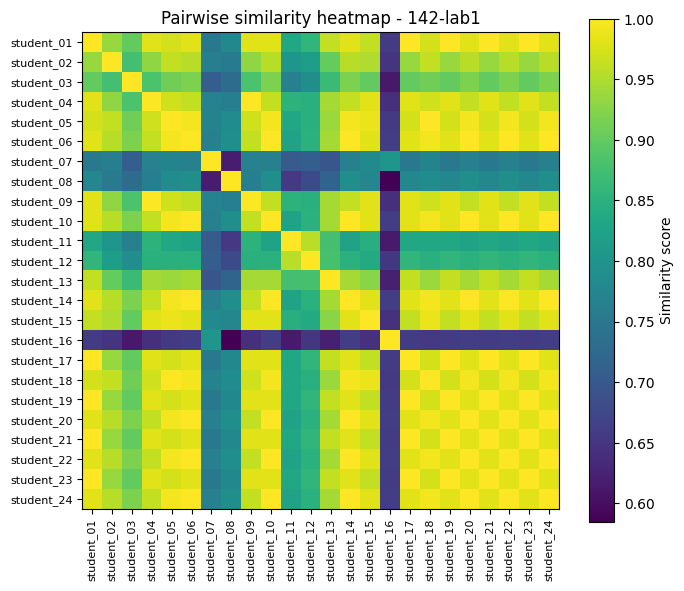

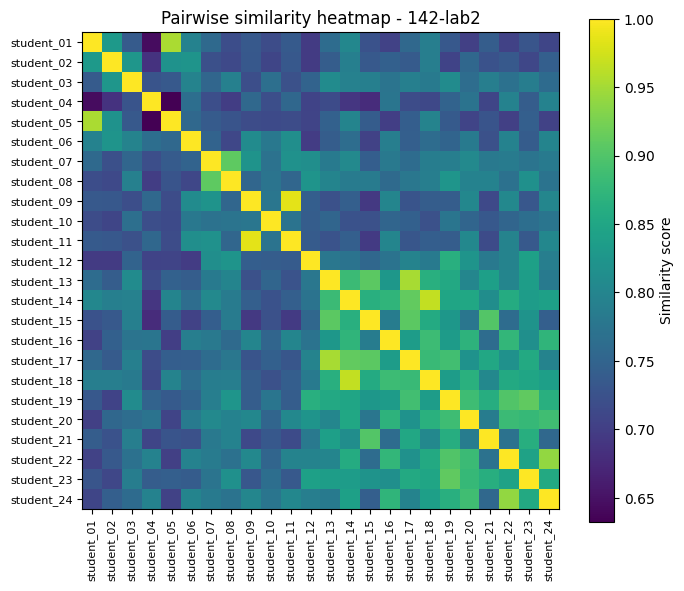

In [8]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "fixtures").exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root.")


repo_root = find_repo_root(Path.cwd().resolve())


def build_pairwise_frame(lab_name: str) -> pd.DataFrame:
    astra_src = str(repo_root / "packages" / "astra-core" / "src")
    if astra_src not in sys.path:
        sys.path.insert(0, astra_src)

    from astra_core import CodeUnit, analyze_code_similarity

    annotations = pd.read_csv(repo_root / "fixtures" / lab_name / "annotations.csv")

    units = [
        CodeUnit(
            id=str(row.student_id),
            content=(repo_root / Path(str(row.file_path))).read_text(),
        )
        for row in annotations.itertuples(index=False)
    ]

    report = analyze_code_similarity(units, threshold=0.8)

    score_map = {
        tuple(sorted((str(s.unit_a), str(s.unit_b)))): s.score for s in report.scores
    }

    rows = []
    for left, right in itertools.combinations(annotations.itertuples(index=False), 2):
        a, b = sorted((str(left.student_id), str(right.student_id)))
        key = (a, b)

        rows.append(
            {
                "lab": lab_name,
                "left": a,
                "right": b,
                "score": score_map[key],
                "actual_same": left.ground_truth_group == right.ground_truth_group,
            }
        )

    return pd.DataFrame(rows)


def summarize_thresholds(
    frame: pd.DataFrame, thresholds=(0.7, 0.8, 0.9)
) -> pd.DataFrame:
    actual = frame["actual_same"]

    out = []
    for t in thresholds:
        pred = frame["score"] >= t

        tp = int((actual & pred).sum())
        tn = int((~actual & ~pred).sum())
        fp = int((~actual & pred).sum())
        fn = int((actual & ~pred).sum())

        out.append(
            {
                "threshold": t,
                "pairs": len(frame),
                "tp": tp,
                "tn": tn,
                "fp": fp,
                "fn": fn,
                "accuracy": (tp + tn) / len(frame),
                "precision": tp / (tp + fp) if tp + fp else np.nan,
                "recall": tp / (tp + fn) if tp + fn else np.nan,
                "f1": (2 * tp / (2 * tp + fp + fn)) if (2 * tp + fp + fn) else np.nan,
            }
        )

    return pd.DataFrame(out)


def plot_heatmap(frame: pd.DataFrame, lab_name: str):
    labels = sorted(set(frame["left"]).union(set(frame["right"])))
    idx = {v: i for i, v in enumerate(labels)}

    mat = np.zeros((len(labels), len(labels)))

    for _, r in frame.iterrows():
        i = idx[r["left"]]
        j = idx[r["right"]]
        mat[i, j] = r["score"]
        mat[j, i] = r["score"]

    np.fill_diagonal(mat, 1.0)

    plt.figure(figsize=(7, 6))
    plt.imshow(mat, interpolation="nearest")
    plt.title(f"Pairwise similarity heatmap - {lab_name}")
    plt.xticks(range(len(labels)), labels, rotation=90, fontsize=8)
    plt.yticks(range(len(labels)), labels, fontsize=8)
    plt.colorbar(label="Similarity score")
    plt.tight_layout()
    plt.show()


analysis = pd.concat(
    [
        build_pairwise_frame("142-lab1"),
        build_pairwise_frame("142-lab2"),
    ],
    ignore_index=True,
)

# Threshold evaluation
for lab, frame in analysis.groupby("lab"):
    print(f"\n{lab} threshold summary")
    print(
        summarize_thresholds(frame, thresholds=(0.7, 0.8, 0.9))
        .round(4)
        .to_string(index=False)
    )

# Heatmaps per lab
for lab, frame in analysis.groupby("lab"):
    plot_heatmap(frame, lab)

The similarity checker performs inconsistently across datasets. Lab 1 shows weak discrimination, with low precision and many false positives despite relatively high recall, indicating over-flagging of similarity. Lab 2 shows better separability, with higher accuracy and a more balanced precision–recall trade-off.

However, both evaluations are based on synthetic LLM-generated data with constructed ground-truth annotations. This limits realism in code variation and plagiarism patterns, so results likely overestimate stability and may not fully reflect real-world performance.

## 8. Discussion

### 8.1 Strengths

Astra is robust against the most common obfuscation techniques applied by students in programming courses. Renaming, reformatting, literal changes, and comment modifications have no effect on similarity scores after AST normalization.

Chunk-level alignment evidence gives instructors a concrete basis for reviewing flagged pairs rather than relying solely on a scalar score.

### 8.2 Weaknesses

Astra operates entirely at the syntactic and structural level. It cannot detect semantic equivalence: two programs that implement the same algorithm through fundamentally different control structures will produce low similarity scores despite being logically equivalent. For example, one using iteration and one using recursion. This is an inherent limitation without semantic analysis.

The current program only accepts Python source files. Other languages such as Java or C++ would require language-specific parsers and normalization rules but could reuse the alignment and aggregation components without modification.

### 8.3 Practical Constraints

The $O(n^2 \cdot k^2 \cdot t^2)$ time complexity limits practical use to small and medium class sizes. The pure Python implementation, while correct and maintainable, does not exploit vectorized computation and becomes noticeably slow beyond approximately 100 files. The system is well-suited to its stated target of 15–30 submissions per analysis run.


## 9. Future Work

**Semantic similarity.** Incorporating AST embeddings or graph neural network models operating on program dependence graphs would enable detection of logically equivalent programs that differ in control structure, addressing the primary limitation of the current approach.

**Multi-language support.** Extending the pipeline to support additional languages such as Java or C++ would require language-specific parsers and normalization rules but could reuse the alignment and aggregation components without modification.


## References

- Burrows, S., Tahaghoghi, S., & Zobel, J. (2018). Efficient plagiarism detection for large code repositories. _AICS 2018 Proceedings._ https://ceur-ws.org/Vol-2259/aics_33.pdf
- Flores, E., Figueira, A., & Curry, E. (2023). A survey on code plagiarism detection. _Applied Sciences, 13_(20), 11358. https://doi.org/10.3390/app132011358
- JPlag. JPlag demo and overview. https://jplag.github.io/Demo/overview
- Ragkhitwetsagul, C., Krinke, J., & Clark, D. (2019). A comparison of code similarity analysers. _ACM Transactions on Software Engineering and Methodology, 28_(1). https://doi.org/10.1145/3313290
- Selvi, S. T., & Sivasakthi, M. (2024). Source code plagiarism detection using AST. _Scientific Journal of Informatics, 11_(1). https://doi.org/10.15294/sji.v11i1.48064
- Yang, D. (2019). How MOSS works. https://yangdanny97.github.io/blog/2019/05/03/MOSS
